Reinforce log vizualizer

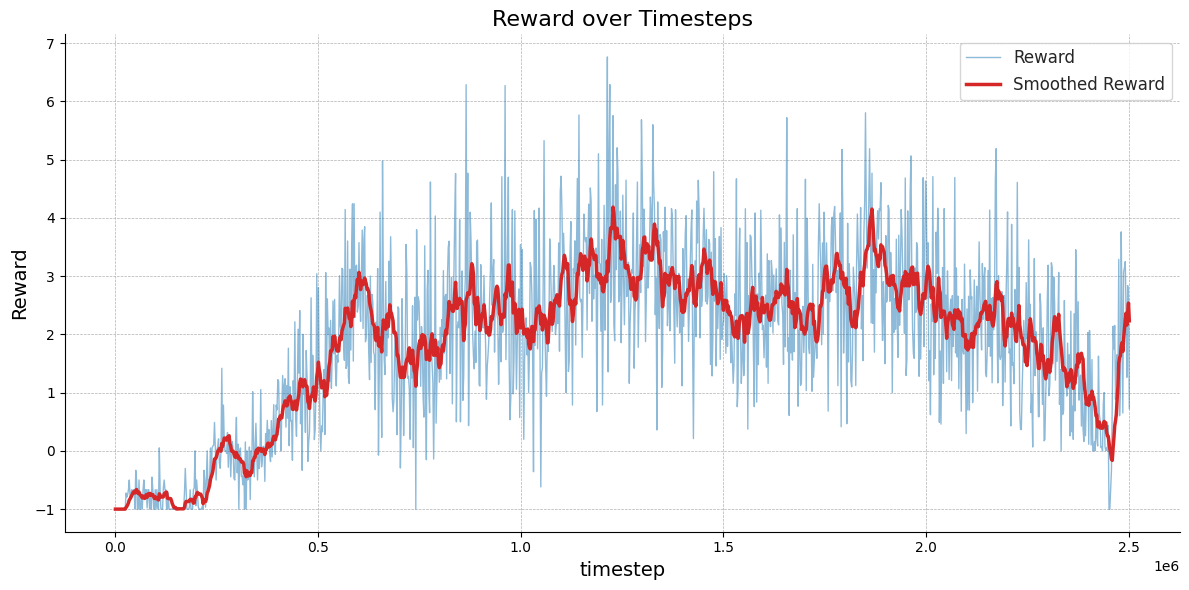

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
# log_path = "logs_corrector/PPO_MainOne/log20250701-140710.csv"
log_path = "../logs_corrector/PPO/environement_normalized/w_noise_stacked/PPONormalJittering_20250702-112256/log.csv"
df = pd.read_csv(log_path, sep=",")



# df = df.where(df['timestep'] <= 2.32e6).dropna(how='all')
# Calculate the moving average (smoothed rewards)logs_corrector/PPO_20250630-141535/log.csv
def plot_rewards(df, window_size = 10 ) :
     # You can adjust the window size as needed
    df['smoothed_reward'] = df['reward'].rolling(window=window_size, min_periods=1).mean()

    # Set the figure size
    plt.figure(figsize=(12, 6))

    # Create the line plot for the original rewards
    sns.lineplot(x="timestep", y="reward", data=df, errorbar=("se", 2),
                color="#1f77b4", linewidth=1, label='Reward', alpha=0.5)

    # Create the line plot for the smoothed rewards
    sns.lineplot(x="timestep", y="smoothed_reward", data=df,
                color="#d62728", linewidth=2.5, label='Smoothed Reward')

    # Add title and labels
    plt.title("Reward over Timesteps", fontsize=16)
    plt.xlabel("timestep", fontsize=14)
    plt.ylabel("Reward", fontsize=14)

    # Customize the grid
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Customize the background and spines
    sns.set_style("whitegrid")
    sns.despine()

plot_rewards(df)
# Show the plot
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

log_path = "../logs_corrector/PPO/environement_normalized/w_noise_stacked"
path = Path(log_path)

log_df = []
rewards = []
timesteps = []
for file in path.glob("PPO*/*.csv"):
    print(file)
    df = pd.read_csv(file).where(df['timestep'] <= 2.32e6).dropna(how='all')
    # df.head()
    log_df.append(df)

    rewards.append(df['reward'].to_numpy())
    print(df['timestep'].to_numpy())
    timesteps.append(df['timestep'].to_numpy())
# log_df = pd.concat(log_df).where(df['timestep'] <= 2.32e6).dropna(how='all')

rewards = np.array(rewards)
timesteps = np.array(timesteps)

# Calculate the mean and confidence intervals
df_rewards = pd.DataFrame(rewards)
best_rewards = df_rewards.max(axis=0)
mean_rewards = df_rewards.mean(axis=0).to_numpy()
conf_interval = 1.96 * df_rewards.sem(axis=0).to_numpy()

# Plot using Seaborn
plt.figure(figsize=(12, 10))
# sns.lineplot(data=df_rewards, palette="muted", alpha=0.2)
plt.plot(timesteps[0], mean_rewards, color='red', label='Mean Reward')
plt.fill_between(timesteps[0],
                 mean_rewards - conf_interval,
                 mean_rewards + conf_interval,
                 color='blue', alpha=0.2, label='95% Confidence Interval')

../logs_corrector/PPO/environement_normalized/w_noise_stacked/PPONormalJittering_20250702-112256/log.csv


NameError: name 'df' is not defined

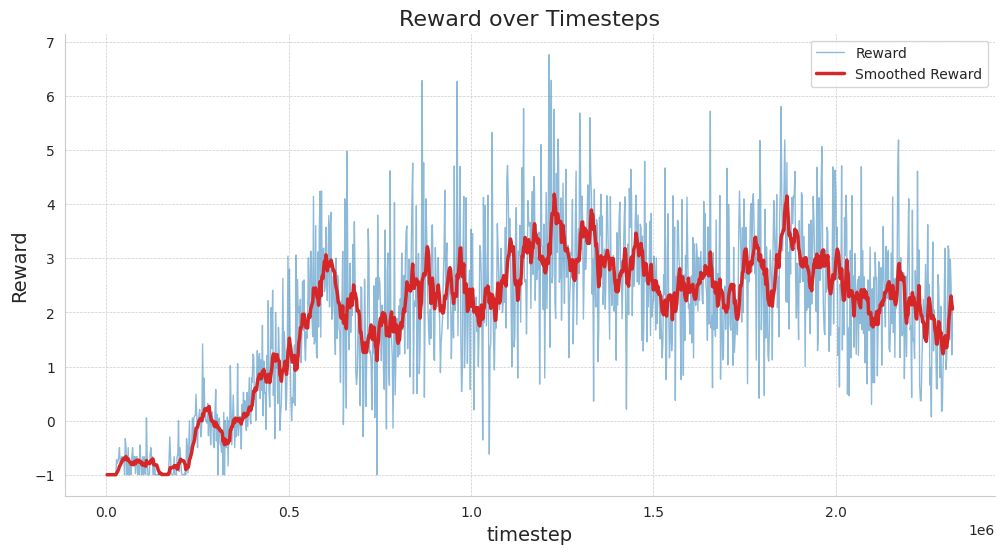

In [5]:
best_rewards = df_rewards.max(axis=0)
mean_rewards = df_rewards.mean(axis=0)

df_best_rewards = pd.DataFrame({'reward': best_rewards, 'timestep': timesteps[0]})
# best_rewards['timestep'] = timesteps[0].tolist()
# df_rewards['reward'] = best_rewards

# best_rewards.loc[:, 'timestep'] = timesteps[0].tolist(
df_best_rewards
plot_rewards(df_best_rewards)

# Learning curves SAC

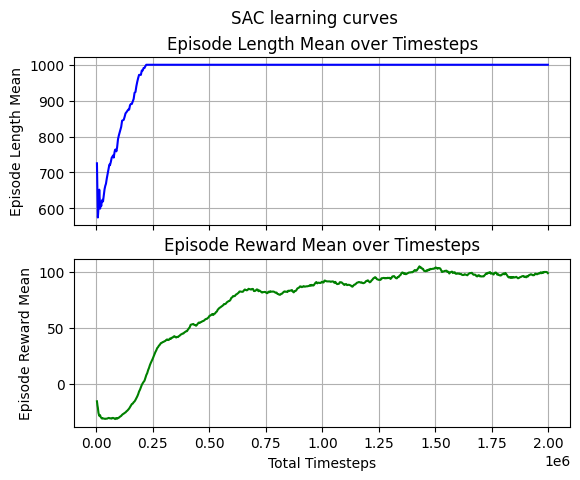

<Figure size 1000x500 with 0 Axes>

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# log_path = "/home/jmartinsaquet/Documents/SmartDartCorrector/logs_corrector/NoneSAC_20250716-135937/progress.csv"
log_path = "/home/jmartinsaquet/Desktop/SmartDart first results /SAC_stacked_20_noise_dist/progress.csv"
df = pd.read_csv(log_path)


fig, axs = plt.subplots(2,1, sharex=True)


# axs = plt.figure(figsize=(10,5)).add_subplot(2,1,1)
pos = 1
sns.lineplot(x="time/total_timesteps", y="rollout/ep_rew_mean", data=df, color="green", ax=axs[pos])
axs[pos].set_xlabel("Total Timesteps")
axs[pos].set_ylabel("Episode Reward Mean")
axs[pos].set_title("Episode Reward Mean over Timesteps")
axs[pos].grid(True)
# plt.show()

pos = 0
# Plot timestep vs episode length mean
plt.figure(figsize=(10,5))
sns.lineplot(x="time/total_timesteps", y="rollout/ep_len_mean", data=df, color="blue", ax=axs[pos])
axs[pos].set_xlabel("Total Timesteps")
axs[pos].set_ylabel("Episode Length Mean")
axs[pos].set_title("Episode Length Mean over Timesteps")
axs[pos].grid(True)

fig.suptitle("SAC learning curves")

fig.savefig("learning_curves_SAC_5_C0.png")
# sns.lineplot(data=df, x="timestep", y="reward")


# Boxplots


10_u_sim_SAC_Noise.csv
10_u_sim_SAC_None.csv
10_u_sim_GRN_None.csv
10_u_simNone_20.0_5.csv
10_u_simNoise_20.0_5.csv
10_u_sim_GRN_Noise.csv
C-I SAC    4.307507
C-U SAC    0.006493
C-U GRN    0.758464
UC-U       0.010031
UC-I       5.409790
C-I GRN    2.065601
dtype: float64


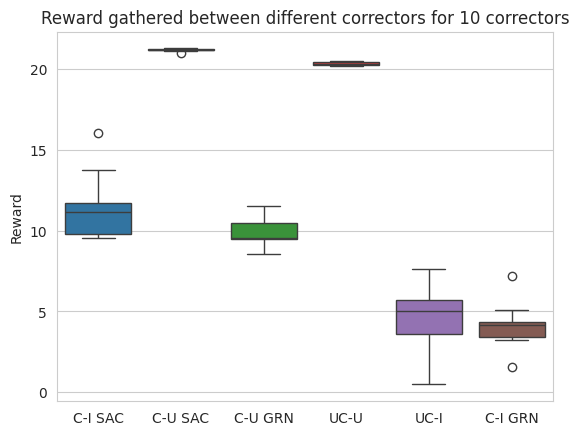

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

log_path = "../logs_corrector/log_normalized_env"
path = Path(log_path)

dfs = []

data = {}

experiments = ["Noise", "None"]
experiment_to_draw = "all"
for file in path.glob("*.csv"):
    print(file.name)

    if experiment_to_draw not in file.name and experiment_to_draw != "all":
        continue
    else:
        df = pd.read_csv(file)
        if "all" == experiment_to_draw:
            if "SAC" in file.name:
                if "Noise" in file.name:
                    data['C-I SAC'] = df.iloc[:, 1]
                elif "None" in file.name:
                    data['C-U SAC'] = df.iloc[:, 1]
            elif "PPO" in file.name:
                if "Noise" in file.name:
                    data['C-I PPO'] = df.iloc[:, 1]
                elif "None" in file.name:
                    data['C-U PPO'] = df.iloc[:, 1]
            elif "GRN" in file.name:
                if "Noise" in file.name:
                    data['C-I GRN'] = df.iloc[:, 1]
                elif "None" in file.name:
                    data['C-U GRN'] = df.iloc[:, 1]
            else:
                if "Noise" in file.name:
                    data['UC-I'] = df.iloc[:, 1]
                elif "None" in file.name:
                    data['UC-U'] = df.iloc[:, 1]


        else:
            if 'SAC' in file.name:
                # print(file.name)
                data['user + SAC'] = df.iloc[:, 1]
            elif 'PPO' in file.name:
                data['PPO'] = df.iloc[:, 1]
            else:
                if "Noise" in file.name:
                    data['impaired user'] = df.iloc[:, 1]
                elif "None" in file.name:
                    data['unimpaired user'] = df.iloc[:, 1]

    # dfs.append(df)

# df = pd.concat(dfs) 
df = pd.DataFrame(data)

sns.boxplot(data=df)
plt.title("Reward gathered between different correctors for 10 correctors")
plt.ylabel("Reward")

print(df.var())

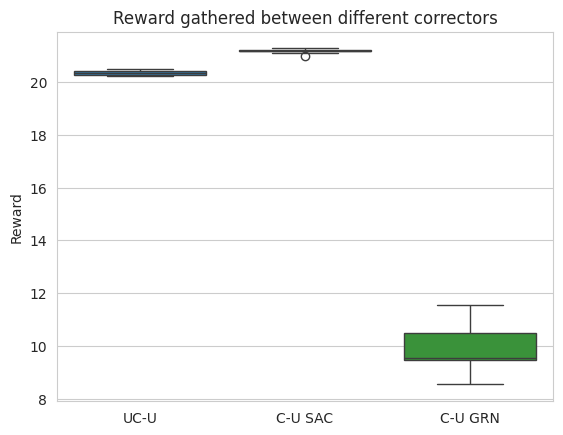

In [22]:
sns.boxplot(data=df[["UC-U","C-U SAC", "C-U GRN"]])
plt.title("Reward gathered between different correctors")
plt.ylabel("Reward")
plt.savefig("unimpaired_vs_impaired.png")

# Visualize learned policy

In [ ]:
import sys
from pathlib import Path
import os 
import time
import matplotlib.pyplot as plt
REPO_ROOT = Path(os.path.abspath('')).resolve().parents[0]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import stable_baselines3 as sb3
from common.rolloutenv import *
from common.perturbation import *

model_path = "/home/jmartinsaquet/Desktop/SmartDart first results /SAC_stacked_20_noise_dist/models/sac_smartdart_final.zip"
# model_path = "/home/jmartinsaquet/Desktop/SmartDart first results /SAC_stacked_5_None/models/sac_smartdart_final.zip"


# GAME_PATH = "../" +  GAME_PATH

# env = smartDartEnv(VITE_USim([0, 0]), None, render=False, n_parallel=1, n_stack=n_stack, normalize=args.normalize, reward_shape=False)
experiments = ["noise", "None"]
experiment_to_draw =  ""

# to check in the hyperparameters file
n_stack = 20
normalized_env = True
policy = ""
if 'SAC' in model_path:
    policy = "SAC"
    model = sb3.SAC.load(model_path, print_system_info=True)
elif 'PPO' in model_path:
    policy = "PPO"
    model = sb3.PPO.load(model_path)

else:
    policy = "unknown"


for e in experiments:
    if e in model_path:
        experiment_to_draw = e


print(f"experiment to draw : {experiment_to_draw}")
print(f"Policy : {policy}")

perturbator = None
if experiment_to_draw == "noise":
    perturbator = NormalJittering(10, 20)

env = smartDartEnv(VITE_USim([0, 0]), perturbator, render=True, n_parallel=1, n_stack=n_stack, normalize=normalized_env, reward_shape=False, game_path="../" + GAME_PATH, speedup=1)



for i in range(1):
    done = False
    obs, _ = env.reset()
    a = []
    o = []
    rewards = []
    while not done:

        o.append(obs[-2:])
        action, _ = model.predict(obs, deterministic=True)
        a.append(action[-2:])
        # print("obs : ", obs, "\t action : ", action) 
        obs, reward, done, _, info = env.step(action)
        # print(f"reward : {reward}")
        rewards.append(reward)
        # time.sleep(0.001)

    print(f"reward gather for ep {i} : {sum(rewards)}")  
    SAC_player_positions = env.player_positions


env.close()


env_usim = env.godot_env
r_sum, r_list, u_sim_player_pos = rolloutSmartDartEnv(env_usim, 10000, perturbator, None) 





ax = plt.figure(figsize=(10,10)).add_subplot()
sac_player_positions = np.array(SAC_player_positions)
sac_tstep = np.arange(sac_player_positions.shape[0])
ax.plot(sac_player_positions[:,0], sac_player_positions[:,1], '.')

ax.set_title(f"Player position over time for {policy} on {experiment_to_draw} perturbation with reward : {sum(rewards)}")

== CURRENT SYSTEM INFO ==
- OS: Linux-6.8.0-65-generic-x86_64-with-glibc2.35 # 68~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue Jul 15 18:06:34 UTC 2
- Python: 3.11.5
- Stable-Baselines3: 2.4.0
- PyTorch: 2.7.1+cu126
- GPU Enabled: True
- Numpy: 1.26.4
- Cloudpickle: 3.1.1
- Gymnasium: 1.0.0

== SAVED MODEL SYSTEM INFO ==
- OS: Linux-6.8.0-60-generic-x86_64-with-glibc2.35 # 63~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue Apr 22 19:00:15 UTC 2
- Python: 3.11.5
- Stable-Baselines3: 2.4.0
- PyTorch: 2.7.1+cu126
- GPU Enabled: True
- Numpy: 1.26.4
- Cloudpickle: 3.1.1
- Gymnasium: 1.0.0



RuntimeError: CUDA error: CUDA-capable device(s) is/are busy or unavailable
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [24]:
from pathlib import Path
import sys
import os
import pandas as pd
from loguru import logger
import wandb
import pprint
from functools import partial
import argparse

REPO_ROOT = Path(os.path.abspath('')).resolve().parents[0]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from common.rolloutenv import *
from common.perturbation import *
# from GA.pyGRN.pygrn import problems, evolution, grns
from pygrn import problems, evolution, grns
from pygrn.problems.reinforcement import ReinforcementLearningTask, set_env_pool, create_env_info
from pygrn.config import *


model_path = "../grns/grns_98a032b6-f396-4036-888c-dfa377a8539a.log"
with open(model_path, "r") as f:
    lines = f.readlines()
    model_string = lines[-1]

# for e in experiments:
#     if e in model_path:
#         experiment_to_draw = e
experiment_to_draw = "None"

print(f"experiment to draw : {experiment_to_draw}")
print(f"Policy : GRN")

perturbator = None
if experiment_to_draw == "noise":
    perturbator = NormalJittering(10, 20)
model = grns.DissetGRN()
model.from_str(model_string)
env = smartDartEnv(VITE_USim([0, 0]), perturbator, render=True, n_parallel=1, n_stack=1, normalize=False, reward_shape=False, game_path="../" + GAME_PATH, speedup=1)

h_act = env.action_space.high
l_act = env.action_space.low

for i in range(1):
    model.setup()
    model.warmup(25)
    done = False
    obs, _ = env.reset()
    a = []
    o = []
    rewards = []
    while not done:
        model.set_input(obs)
        model.step()
        o.append(obs[-2:])
        action = model.get_output() * (h_act - l_act) + l_act
        a.append(action[-2:])
        # print("obs : ", obs, "\t action : ", action) 
        obs, reward, done, _, info = env.step(action)
        # print(f"reward : {reward}")
        rewards.append(reward)
        grn_player_positions = env.player_positions
        # time.sleep(0.001)

    print(f"reward gather for ep {i} : {sum(rewards)}")

experiment to draw : None
Policy : GRN
waiting for remote GODOT connection on port 11008
Godot Engine v4.4.1.stable.mono.official.49a5bc7b6 - https://godotengine.org
OpenGL API 3.3.0 NVIDIA 535.247.01 - Compatibility - Using Device: NVIDIA - NVIDIA RTX 2000 Ada Generation Laptop GPU

dist max is 2202.9071700823
getting command line arguments
--port=11008
--env_seed=0
--speedup=1
--num_envs=1
{ "port": "11008", "env_seed": "0", "speedup": "1", "num_envs": "1" }
{ "port": "11008", "env_seed": "0", "speedup": "1", "num_envs": "1" }
{ "port": "11008", "env_seed": "0", "speedup": "1", "num_envs": "1" }
physics ticks 60 1.0 1.0 8.0
Waiting for one second to allow server to start
trying to connect to server
performing handshake
connection established
handshake complete
action space [{'move_action': {'size': 2, 'action_type': 'continuous'}, 'click_action': {'size': 1, 'action_type': 'discrete'}}]
observation space [{'obs': {'size': [4], 'space': 'box'}}]
reward gather for ep 0 : 10.74399983882

Text(0.5, 1.0, 'C-I')

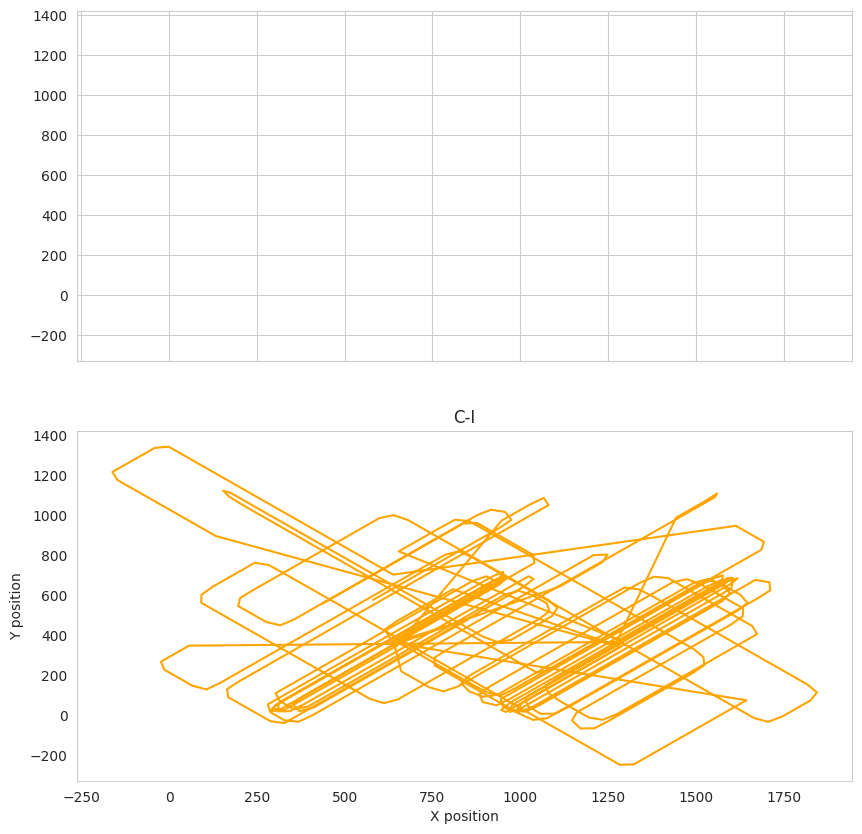

In [27]:
import matplotlib.pyplot as plt
import tol_colors as tc

# cset = tc.bright
dark_green = "#006400"  # UC
orange = "orange"       # C
fig, axs =plt.subplots(2,1, sharex=True, sharey=True, figsize=(10,10))

ax = axs[1]
# sac_player_positions = np.array(SAC_player_positions)

sac_player_positions = np.array(grn_player_positions)
sac_tstep = np.arange(sac_player_positions.shape[0])
ax.plot(sac_player_positions[:,0], sac_player_positions[:,1], '-', label="SAC", color=orange)
ax.set_ylabel("Y position")
ax.set_xlabel("X position")
ax.grid()
ax.set_title(f"C-I")


# ax = axs[0]
# u_sim_player_pos = np.array(u_sim_player_pos)
# ax.plot(u_sim_player_pos[:,0], u_sim_player_pos[:,1], '.', label="USim", color=dark_green)
# ax.grid()
# ax.set_title(f"UC-I")

# ax.set_ylabel("Y position")
# ax.set_xlabel("X position")
# ax.set_ylim(0, 1200)
# ax.invert_yaxis()

# plt.savefig(f"player_position_{policy}_{experiment_to_draw}.png")

# # u_sim_player_pos.shape
# sac_player_positions.shape
# SAC_player_positions = sac_player_positions

create heatmap

In [32]:
a

[array([-18.51365673, -19.51090603]),
 array([ -7.42512991, -10.38387944]),
 array([ 3.00601842, -1.91214161]),
 array([12.84189117,  5.96699824]),
 array([22.1237644 , 13.29699679]),
 array([30.87477623, 20.10456794]),
 array([39.10233167, 26.40190957]),
 array([40.        , 32.18871257]),
 array([40.        , 37.45399175]),
 array([40., 40.]),
 array([40., 40.]),
 array([40., 40.]),
 array([40., 40.]),
 array([40., 40.]),
 array([40., 40.]),
 array([40., 40.]),
 array([40., 40.]),
 array([40., 40.]),
 array([40.        , 39.49465762]),
 array([40.        , 38.37598404]),
 array([39.75276732, 36.63835929]),
 array([38.85070446, 34.28025934]),
 array([37.29304553, 31.30165704]),
 array([35.08097643, 27.7048135 ]),
 array([32.2184489 , 23.49499976]),
 array([28.71291928, 18.6811513 ]),
 array([24.576013  , 13.27645638]),
 array([19.82411649,  7.29887915]),
 array([14.478895  ,  0.77161594]),
 array([ 8.56773615, -6.27651565]),
 array([  2.12411666, -13.81075778]),
 array([ -4.81210959, 

NameError: name 'u_sim_player_pos' is not defined

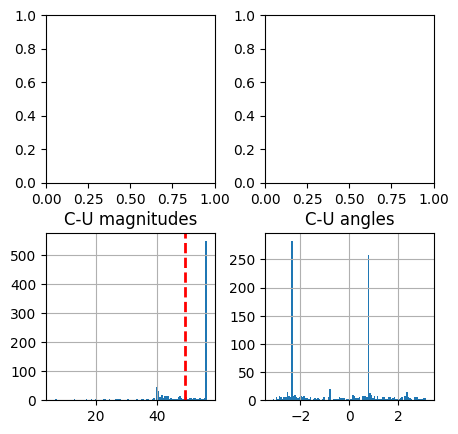

In [17]:
import numpy as np
import pandas as pd


fig, axs =plt.subplots(2,2, figsize=(5,5))

uc_u_index = 0
c_u_index = 1

Pd = np.diff(np.array(SAC_player_positions), axis=0, prepend=0)
sac_disp = np.linalg.norm(Pd, axis=1)
sac_ang = np.arctan2(Pd[:,1], Pd[:,0])
sac_disp_df = pd.DataFrame({"C-U magnitudes": sac_disp, "timestep": sac_tstep, "C-U angles": sac_ang})
sac_disp_df = sac_disp_df[sac_disp_df["C-U magnitudes"] < 80] 

sac_disp_df.hist(column='C-U magnitudes', bins=100, ax=axs[c_u_index][0])
sac_disp_df.hist(column='C-U angles', bins=100, ax=axs[c_u_index][1])

mean = sac_disp_df["C-U magnitudes"].mean()
axs[c_u_index][0].axvline(mean, color='r', linestyle='dashed', linewidth=2)





Pd = np.diff(np.array(u_sim_player_pos), axis=0, prepend=0)
usim_disp = np.linalg.norm(Pd, axis=1)
usim_tstep = np.arange(u_sim_player_pos.shape[0])



u_sim_ang = np.arctan2(Pd[:,1], Pd[:,0])
usim_disp_df = pd.DataFrame({"UC-U magnitudes": usim_disp, "timestep": usim_tstep, "UC-U angles": u_sim_ang})
usim_disp_df = usim_disp_df[usim_disp_df["UC-U magnitudes"] < 80] 
mean = usim_disp_df["UC-U magnitudes"].mean()
axs[uc_u_index][0].axvline(mean, color='r', linestyle='dashed', linewidth=2)

usim_disp_df.hist(column="UC-U magnitudes", bins=100, ax=axs[uc_u_index][0])
usim_disp_df.hist(column="UC-U angles", bins=100, ax=axs[uc_u_index][1]) 
fig.savefig("hist_magnitudes_U_sac.png")



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tol_colors as tc
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

sns.set_style("whitegrid")

# Define colors
dark_green = "#006400"  # UC-U
orange = "orange"       # C-U

c_label = "C-I"
uc_label = "UC-I"

bins = 100

# -------- SAC (C-U) -------- #
Pd = np.diff(np.array(SAC_player_positions), axis=0, prepend=0)
sac_disp = np.linalg.norm(Pd, axis=1)
sac_ang = np.arctan2(Pd[:, 1], Pd[:, 0])
sac_disp_df = pd.DataFrame({
    "Magnitude": sac_disp,
    "Angle": sac_ang,
    "Type": c_label
})
sac_disp_df = sac_disp_df[sac_disp_df["Magnitude"] < 100 ]

# -------- USIM (UC-U) -------- #
Pd = np.diff(np.array(u_sim_player_pos), axis=0, prepend=0)
usim_disp = np.linalg.norm(Pd, axis=1)
u_sim_ang = np.arctan2(Pd[:, 1], Pd[:, 0])
usim_disp_df = pd.DataFrame({
    "Magnitude": usim_disp,
    "Angle": u_sim_ang,
    "Type": uc_label
})
usim_disp_df = usim_disp_df[usim_disp_df["Magnitude"] < 80]

# Combine datasets
df_all = pd.concat([sac_disp_df, usim_disp_df], ignore_index=True)

# -------- Create figure -------- #
fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# -------- Magnitudes Plot -------- #
palette = [dark_green, orange] if df_all.loc[0]["Type"] == uc_label else [orange, dark_green]
sns.histplot(data=df_all, x="Magnitude", hue="Type", stat="density", common_norm=False,
             bins=bins, ax=axs[0], palette=palette, alpha=0.5)
uc_mean = usim_disp_df["Magnitude"].mean()
cu_mean = sac_disp_df["Magnitude"].mean()
# Mean lines
uc_mean_line = axs[0].axvline(uc_mean, color=dark_green, linestyle="--", linewidth=2)
cu_mean_line = axs[0].axvline(cu_mean, color=orange, linestyle="--", linewidth=2)

axs[0].set_title("Magnitudes", fontsize=14, weight="bold")
axs[0].set_xlabel("Magnitude")
axs[0].set_ylabel("Density")

# -------- Angles Plot -------- #
sns.histplot(data=df_all, x="Angle", hue="Type", stat="density", common_norm=False,
             bins=bins, ax=axs[1], palette=palette, alpha=0.5)

axs[1].set_title("Angles", fontsize=14, weight="bold")
axs[1].set_xlabel("Angle (radians)")
axs[1].set_ylabel("Density")

# Format angle axis with multiples of π
axs[1].xaxis.set_major_locator(ticker.MultipleLocator(base=np.pi/2))
axs[1].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda val, _: { -np.pi: r"$-\pi$", -np.pi/2: r"$-\pi/2$",
                      0: r"$0$", np.pi/2: r"$\pi/2$", np.pi: r"$\pi$" }.get(val, f"{val/np.pi:.2f}$\pi$")
))

# -------- Create single legend -------- #
# Legend for bars
uc_patch = mpatches.Patch(color=dark_green, alpha=0.5, label=uc_label)
cu_patch = mpatches.Patch(color=orange, alpha=0.5, label=c_label)
# Legend for mean lines
uc_mean_line_handle = mlines.Line2D([], [], color=dark_green, linestyle="--", linewidth=2, label=uc_label + " Mean")
cu_mean_line_handle = mlines.Line2D([], [], color=orange, linestyle="--", linewidth=2, label=c_label + " Mean")

# Add mean values as text
axs[0].text(uc_mean + 1, axs[0].get_ylim()[1]*0.9, f"{uc_mean:.2f}", color=dark_green, weight="bold")
axs[0].text(cu_mean + 1, axs[0].get_ylim()[1]*0.8, f"{cu_mean:.2f}", color=orange, weight="bold")


# remove the legends 
for ax in axs:
    ax.legend().remove()


# Add the legend to the figure
fig.legend(handles=[uc_patch, cu_patch, uc_mean_line_handle, cu_mean_line_handle],
           loc="center", ncol=4, fontsize=12, frameon=True, title="Legend", draggable=True, bbox_to_anchor=(0.5, 0.85))

# -------- Final touches -------- #
fig.suptitle("Histograms of Magnitudes (Left) and Angles (Right)\nUC-U vs C-U",
             fontsize=16, weight="bold", y=1.00)


plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space at the top for legend
plt.show()
# fig.savefig("hist_magnitudes_I_sac.png")


NameError: name 'SAC_player_positions' is not defined

In [54]:
df_all.loc[0]["Type"] == c_label

True

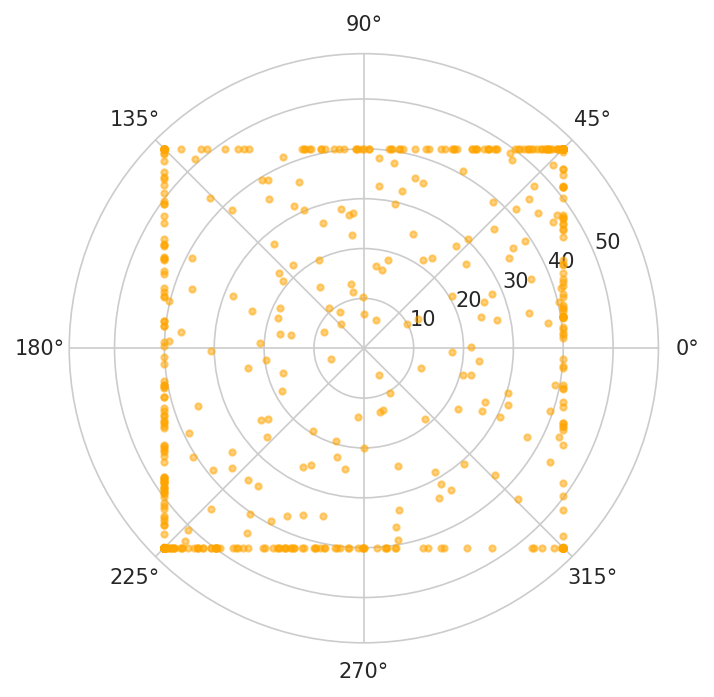

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tol_colors as tc
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

sns.set_style("whitegrid")

# Define colors
dark_green = "#006400"  # UC-U
orange = "orange"       # C-U

c_label = "C-I"
uc_label = "UC-I"

bins = 100

# -------- SAC (C-U) -------- #
Pd = np.diff(np.array(SAC_player_positions), axis=0, prepend=0)
sac_disp = np.linalg.norm(Pd, axis=1)
sac_ang = np.arctan2(Pd[:, 1], Pd[:, 0])
sac_disp_df = pd.DataFrame({
    "Magnitude": sac_disp,
    "Angle": sac_ang,
    "Type": c_label
})
sac_disp_df = sac_disp_df[sac_disp_df["Magnitude"] < 100 ]

# # -------- USIM (UC-U) -------- #
# Pd = np.diff(np.array(u_sim_player_pos), axis=0, prepend=0)
# usim_disp = np.linalg.norm(Pd, axis=1)
# u_sim_ang = np.arctan2(Pd[:, 1], Pd[:, 0])
# usim_disp_df = pd.DataFrame({
#     "Magnitude": usim_disp,
#     "Angle": u_sim_ang,
#     "Type": uc_label
# })
# usim_disp_df = usim_disp_df[usim_disp_df["Magnitude"] < 80]

# Combine datasets
# df_all = pd.concat([sac_disp_df, usim_disp_df], ignore_index=True)

df_all = sac_disp_df

# -------- Create figure -------- #
fig, axs = plt.subplots(1, 1, figsize=(12, 5), dpi=150,  subplot_kw={'projection': 'polar'})

# -------- Magnitudes Plot -------- #
axs.plot(sac_disp_df["Angle"], sac_disp_df["Magnitude"], '.', color=orange, alpha=0.5)
# axs.plot(usim_disp_df["Angle"], usim_disp_df["Magnitude"], '.', color=dark_green, alpha=0.5)

# sns.histplot(data=df_all, x="Magnitude", hue="Type", stat="density", common_norm=False,
#              bins=bins, ax=axs[0], palette=[dark_green, orange], alpha=0.5)
# uc_mean = usim_disp_df["Magnitude"].mean()
# cu_mean = sac_disp_df["Magnitude"].mean()



# Mean lines
# uc_mean_line = axs[0].axvline(uc_mean, color=dark_green, linestyle="--", linewidth=2)
# cu_mean_line = axs[0].axvline(cu_mean, color=orange, linestyle="--", linewidth=2)

# axs[0].set_title("Magnitudes", fontsize=14, weight="bold")
# axs[0].set_xlabel("Magnitude")
# axs[0].set_ylabel("Density")

# # -------- Angles Plot -------- #
# sns.histplot(data=df_all, x="Angle", hue="Type", stat="density", common_norm=False,
#              bins=bins, ax=axs[1], palette=[dark_green, orange], alpha=0.5)

# axs[1].set_title("Angles", fontsize=14, weight="bold")
# axs[1].set_xlabel("Angle (radians)")
# axs[1].set_ylabel("Density")

# # Format angle axis with multiples of π
# axs[1].xaxis.set_major_locator(ticker.MultipleLocator(base=np.pi/2))
# axs[1].xaxis.set_major_formatter(ticker.FuncFormatter(
#     lambda val, _: { -np.pi: r"$-\pi$", -np.pi/2: r"$-\pi/2$",
#                       0: r"$0$", np.pi/2: r"$\pi/2$", np.pi: r"$\pi$" }.get(val, f"{val/np.pi:.2f}$\pi$")
# ))

# # -------- Create single legend -------- #
# # Legend for bars
# uc_patch = mpatches.Patch(color=dark_green, alpha=0.5, label="UC-U")
# cu_patch = mpatches.Patch(color=orange, alpha=0.5, label="C-U")
# # Legend for mean lines
# uc_mean_line_handle = mlines.Line2D([], [], color=dark_green, linestyle="--", linewidth=2, label="UC-U Mean")
# cu_mean_line_handle = mlines.Line2D([], [], color=orange, linestyle="--", linewidth=2, label="C-U Mean")

# # Add mean values as text
# axs[0].text(uc_mean + 1, axs[0].get_ylim()[1]*0.9, f"{uc_mean:.2f}", color=dark_green, weight="bold")
# axs[0].text(cu_mean + 1, axs[0].get_ylim()[1]*0.8, f"{cu_mean:.2f}", color=orange, weight="bold")


# # remove the legends 
# for ax in axs:
#     ax.legend().remove()


# # Add the legend to the figure
# fig.legend(handles=[uc_patch, cu_patch, uc_mean_line_handle, cu_mean_line_handle],
#            loc="center", ncol=4, fontsize=12, frameon=True, title="Legend", draggable=True, bbox_to_anchor=(0.5, 0.85))

# # -------- Final touches -------- #
# fig.suptitle("Histograms of Magnitudes (Left) and Angles (Right)\nUC-U vs C-U",
#              fontsize=16, weight="bold", y=1.00)


plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space at the top for legend
plt.show()
# fig.savefig("hist_magnitudes_I_sac.png")

/tmp/ipykernel_10665/3678793451.py:55: DeprecationWarning: tol_cmap is soft-deprecated since 2.0, please use tol_colors.colormaps, tol_colors.rainbow_discrete instead
  cmap = tc.tol_cmap('rainbow')  # Check if this exists in your version


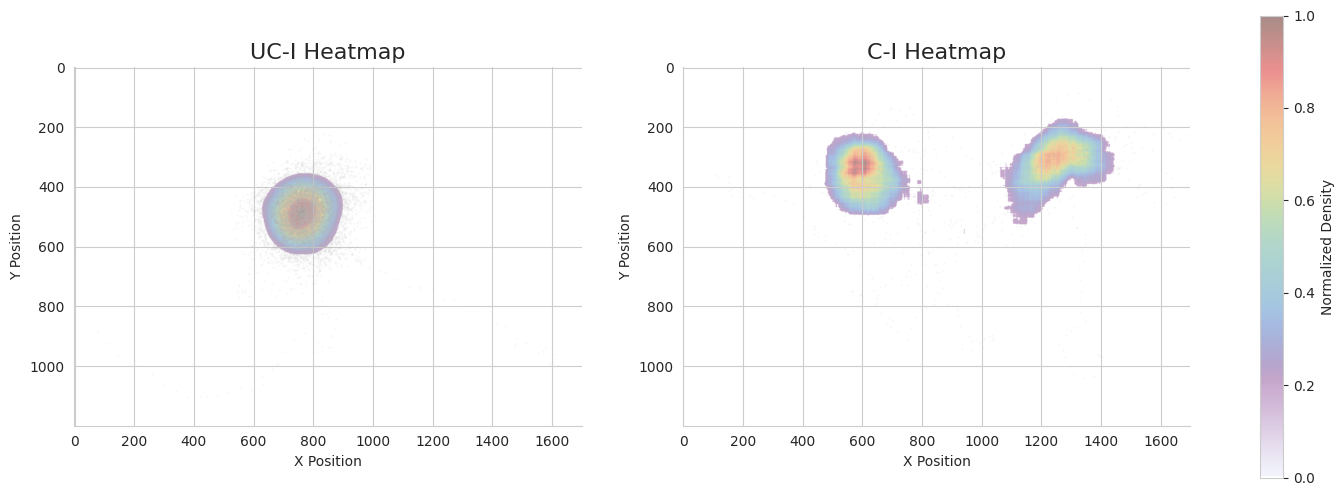

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tol_colors as tc
from matplotlib.colors import ListedColormap

def create_heatmap(points, ax):
# Define the two points (x, y coordinates)

    # Define the size of the output heatmap
    width, height = 1700, 1200
    
    # Create an empty heatmap
    heatmap = np.zeros((height, width))

    # Define the kernel size and standard deviation for the Gaussian
    kernel_size = 100
    sigma = 100

    # Function to create a 2D Gaussian kernel
    def get_gaussian_2d(ksize, sigma):
        one_d = np.outer(np.exp(-np.arange(-ksize//2, ksize//2+1)**2 / (2*sigma**2)),
                        np.exp(-np.arange(-ksize//2, ksize//2+1)**2 / (2*sigma**2)))
        return one_d / np.sum(one_d)

    kernel = np.ones((kernel_size, kernel_size))

    # Create the Gaussian kernel
    kernel = get_gaussian_2d(kernel_size, sigma)

    # Add the Gaussian kernel centered at each point
    for x, y in points:
        # Convert to integer indices
        x, y = int(x), int(y)
        y = 0 if y <0 else y 
        x = 0 if x <0 else x

        y = height - 1 if y > height - 1 else y
        x = width - 1 if x > width - 1 else x
        # Calculate the bounds for the kernel
        start_x = max(0, x - kernel_size//2)
        end_x = min(width, x + kernel_size//2 + 1)
        start_y = max(0, y - kernel_size//2)
        end_y = min(height, y + kernel_size//2 + 1)
        # Add the kernel to the heatmap
        heatmap[start_y:end_y, start_x:end_x] += kernel[
            kernel_size//2 - (y - start_y):kernel_size//2 + (end_y - y),
            kernel_size//2 - (x - start_x):kernel_size//2 + (end_x - x)
        ]

    # heatmap = heatmap / len(points)
    heatmap = heatmap / np.max(heatmap)
    heatmap = heatmap * (heatmap > 0.2) # filter all the values below 0.001
    # Display the heatmap
    # plt.imshow(heatmap, cmap=tc.iridescent)
    cmap = tc.tol_cmap('rainbow')  # Check if this exists in your version
    colors = cmap(np.linspace(0, 1, 256))
    colors[0] = [1, 1, 1, 1]  # White start
    cmap = ListedColormap(colors)


    im = ax.imshow(heatmap, cmap=cmap, alpha=0.5)
    return ax, im


sac_points = np.array(SAC_player_positions)
usim_points = np.array(u_sim_player_pos)

fig, axs = plt.subplots(1, 2, figsize=(18, 6), dpi=100)
color = tc.bright.grey
alpha = 0.5

c_u_index = 1
uc_u_index = 0

axs[c_u_index].plot(sac_points[:,0], sac_points[:,1], '.', label="SAC", color=color, alpha=alpha, markersize=1)
axs[uc_u_index].plot(usim_points[:,0], usim_points[:,1], '.', label="user", color=color, alpha=alpha, markersize=1)

# Create heatmaps


ax, im = create_heatmap(sac_points, axs[c_u_index])
ax, im = create_heatmap(usim_points, axs[uc_u_index])

# Titles
axs[c_u_index].set_title("C-I Heatmap", fontsize=16)
axs[uc_u_index].set_title("UC-I Heatmap", fontsize=16)

# Axis labels
for ax in axs:
    ax.set_xlabel("X Position", fontsize=10)
    ax.set_ylabel("Y Position", fontsize=10)
    ax.tick_params(axis="both", which="both", labelsize=10)
    # Remove spines for a cleaner look
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# Colorbar
cbar = fig.colorbar(im, ax=axs.ravel().tolist())
cbar.set_label("Normalized Density", fontsize=10)

# Main title
# fig.suptitle("Heatmap of Player Positions", fontsize=20, weight="bold", y=1.02)

# Adjust layout
# plt.tight_layout()
# for ax in axs:
#     ax.set_xlim(400, 1500)
#     ax.set_ylim(200, 900)
plt.show()

fig.savefig("heatmap_I_SAC.png")

(50, 50)

In [165]:
# np.array(SAC_player_positions)
# kernel = get_gaussian_2d(kernel_size, sigma)y
SAC_player_positions

[array([437., 559.]),
 array([398.43890381, 578.66619873]),
 array([359.87780762, 541.78625488]),
 array([398.43890381, 580.34735107]),
 array([391.43615723, 618.90844727]),
 array([429.99725342, 580.34735107]),
 array([468.55834961, 541.78625488]),
 array([507.1194458 , 503.22515869]),
 array([545.68054199, 464.6640625 ]),
 array([584.24163818, 426.10296631]),
 array([622.80273438, 387.54187012]),
 array([661.36383057, 348.98077393]),
 array([658.5333252 , 310.41967773]),
 array([619.972229  , 347.27502441]),
 array([581.41113281, 384.13562012]),
 array([542.85003662, 372.46035767]),
 array([581.41113281, 333.89926147]),
 array([619.972229  , 295.33816528]),
 array([658.5333252 , 256.79293823]),
 array([668.05603027, 284.99212646]),
 array([659.48046875, 323.55322266]),
 array([649.38476562, 362.11431885]),
 array([1684.35632324,  154.56109619]),
 array([1676.06530762,  150.95599365]),
 array([1637.50415039,  112.39488983]),
 array([1598.94299316,   73.83378601]),
 array([1560.3818359

In [2]:
path = "../grns/grns_314498e1-21e5-4d5c-8d72-44ace86c353b.log"

with open(path, "r") as f:
    lines = f.readlines()
    print(lines[-1])

{"num_input": 2, "num_output": 2, "num_regulatory": 1, "ids": [0.18329179208884516, 0.3237270452762322, 0.6952235323149762, 0.5503658230412025, 0.44026992337505133], "enh": [0.037159016001638734, 0.7784147112382281, 0.9581298657269732, 0.08421919723941163, 0.5115664271900171], "inh": [0.619141304371568, 0.5985019714530883, 0.10332911123704625, 0.718581007882897, 0.4277978946870127], "beta": 1.1420937744140085, "delta": 1.8171121347358514}

